"""
Car price dataset inspection, cleaning, predicting workflow.

Goal:
- Understand raw data quality
- Visualize target distribution
- Clean obvious datatype issues
- Remove duplicates and extreme price outliers
- Re-visualize after cleaning
- Train test split
- Build baseline linear regression model
- Build random forest model
- Give fiat 500 example
"""

In [1]:
# basic packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# stat packages
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

In [3]:
# env variables
DATA_PATH = "car_price_prediction.csv"
TARGET_COLUMN = "Price"
PRICE_UPPER_QUANTILE = 0.99
DROP_COLUMNS = ["ID"]
RANDOM_STATE = 42

In [4]:
def load_data(path):
    """Load dataset from CSV."""
    return pd.read_csv(path)


def inspect_dataframe(df):
    """Print basic dataframe diagnostics."""
    print("\n--- HEAD ---")
    print(df.head())

    print("\n--- INFO ---")
    print(df.info())

    print("\n--- DESCRIBE NUMERIC ---")
    print(df.describe())

    print("\n--- DESCRIBE ALL ---")
    print(df.describe(include="all"))

    print("\n--- MISSING VALUES ---")
    print(df.isna().sum().sort_values(ascending=False))

    print("\n--- DUPLICATES ---")
    print(df.duplicated().sum())

    print("\n--- DTYPES ---")
    print(df.dtypes)


def inspect_column_values(df, columns, n_values=20):
    """Print value counts or examples for selected columns."""
    for column in columns:
        if column not in df.columns:
            continue

        print(f"\n--- {column} ---")
        print(df[column].value_counts(dropna=False).head(n_values))


def plot_price_distribution(df, title_suffix=""):
    """Plot histogram and boxplot of the original price."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df[TARGET_COLUMN], bins=50, ax=axes[0])
    axes[0].set_title(f"Price Histogram {title_suffix}")
    axes[0].set_xlabel("Price")

    sns.boxplot(y=df[TARGET_COLUMN], ax=axes[1])
    axes[1].set_title(f"Price Boxplot {title_suffix}")
    axes[1].set_ylabel("Price")

    plt.tight_layout()
    plt.show()


def plot_log_price_distribution(df, title_suffix=""):
    """Plot histogram of log-transformed price."""
    log_price = np.log1p(df[TARGET_COLUMN])

    plt.figure(figsize=(8, 5))
    sns.histplot(log_price, bins=50)
    plt.title(f"Log Price Histogram {title_suffix}")
    plt.xlabel("log1p(Price)")
    plt.tight_layout()
    plt.show()


def plot_top_categories(df, column, top_n=15):
    """Plot top categories for a categorical column."""
    if column not in df.columns:
        return

    top_counts = df[column].value_counts().head(top_n)

    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=top_counts.values,
        y=top_counts.index,
        orient="h",
    )
    plt.title(f"Top {top_n} values for {column}")
    plt.xlabel("Count")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()


def plot_numeric_column(df, column):
    """Plot histogram and boxplot for a numeric column."""
    if column not in df.columns:
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df[column].dropna(), bins=50, ax=axes[0])
    axes[0].set_title(f"{column} Histogram")

    sns.boxplot(y=df[column], ax=axes[1])
    axes[1].set_title(f"{column} Boxplot")

    plt.tight_layout()
    plt.show()


def clean_numeric_from_string(df, column):
    """Extract numeric part from a string column and convert to float."""
    df = df.copy()

    if column not in df.columns:
        return df

    df[column] = (
        df[column]
        .astype(str)
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
    )

    return df


def clean_levy(df):
    """Clean Levy column by replacing non-numeric placeholders."""
    df = df.copy()

    if "Levy" not in df.columns:
        return df

    df["Levy"] = (
        df["Levy"]
        .replace("-", np.nan)
        .astype(str)
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
    )

    return df


def remove_duplicates(df):
    """Remove duplicate rows."""
    before = len(df)
    df = df.drop_duplicates()
    after = len(df)

    print(f"Removed {before - after} duplicate rows.")

    return df


def remove_invalid_prices(df):
    """Remove rows with invalid target values."""
    before = len(df)

    df = df[
        df[TARGET_COLUMN].notna()
        & (df[TARGET_COLUMN] > 0)
    ]

    after = len(df)
    print(f"Removed {before - after} rows with invalid prices.")

    return df


def remove_price_outliers(df, upper_quantile=PRICE_UPPER_QUANTILE):
    """Remove extreme price outliers based on upper quantile."""
    before = len(df)
    upper_limit = df[TARGET_COLUMN].quantile(upper_quantile)

    df = df[df[TARGET_COLUMN] <= upper_limit]

    after = len(df)

    print(f"Price upper limit: {upper_limit:,.2f}")
    print(f"Removed {before - after} price outlier rows.")

    return df

def remove_mileage_outliers(df, max_mileage=1_000_000):
    """Remove unrealistic mileage values."""
    df = df.copy()

    before = len(df)

    df = df[
        df["Mileage"].isna()
        | (df["Mileage"] <= max_mileage)
    ]

    after = len(df)

    print(f"Maximum mileage allowed: {max_mileage:,.0f}")
    print(f"Removed {before - after} mileage outlier rows.")

    return df

def clean_dataframe(
    df,
    remove_outliers=True,
    upper_quantile=PRICE_UPPER_QUANTILE,
):
    """Main cleaning pipeline."""
    df = df.copy()

    df = remove_duplicates(df)
    df = remove_invalid_prices(df)

    df = clean_numeric_from_string(df, "Mileage")
    df = clean_numeric_from_string(df, "Engine volume")
    df = clean_levy(df)

    if remove_outliers:
        df = remove_price_outliers(
            df,
            upper_quantile=upper_quantile,
        )

        df = remove_mileage_outliers(
        df,
        max_mileage=600000,
        )

    return df

def fill_missing_numeric_with_median(df, columns):
    """Fill missing numeric values with the column median."""
    df = df.copy()

    for column in columns:
        if column not in df.columns:
            continue

        missing_before = df[column].isna().sum()

        if missing_before > 0:
            median_value = df[column].median()
            df[column] = df[column].fillna(median_value)

            print(
                f"Filled {missing_before} missing values in {column} "
                f"with median: {median_value:,.2f}"
            )

    return df

In [20]:
def main():
    """Run full inspection and cleaning workflow."""
    raw_df = load_data(DATA_PATH)

    print("\n================ RAW DATA INSPECTION ================")
    inspect_dataframe(raw_df)

    print("\n================ RAW TARGET PLOTS ================")
    plot_price_distribution(raw_df, title_suffix="Before Cleaning")
    plot_log_price_distribution(raw_df, title_suffix="Before Cleaning")

    print("\n================ CATEGORICAL INSPECTION ================")
    categorical_columns = [
        "Manufacturer",
        "Model",
        "Category",
        "Fuel type",
        "Gear box type",
        "Drive wheels",
        "Doors",
        "Wheel",
        "Color",
    ]

    inspect_column_values(raw_df, categorical_columns)

    plot_top_categories(raw_df, "Manufacturer", top_n=15)
    plot_top_categories(raw_df, "Category", top_n=15)
    plot_top_categories(raw_df, "Fuel type", top_n=15)


    print("\n================ SUSPICIOUS RAW COLUMNS ================")
    suspicious_columns = [
        "Levy",
        "Mileage",
        "Engine volume",
        "Doors",
    ]

    inspect_column_values(raw_df, suspicious_columns)

    print("\n================ CLEANING DATA ================")
    clean_df = clean_dataframe(
        raw_df,
        remove_outliers=True,
        upper_quantile=0.99,
    )

    print("\n================ MISSING VALUE IMPUTATION ================")
    clean_df = fill_missing_numeric_with_median(
        clean_df,
        columns=[
            "Levy",
        ],
    )

    print("\nMissing values after imputation:")
    print(clean_df.isna().sum().sort_values(ascending=False).head(10))

    print("\n================ CLEANED DATA INSPECTION ================")
    inspect_dataframe(clean_df)

    print("\n================ CLEANED TARGET PLOTS ================")
    plot_price_distribution(clean_df, title_suffix="After Cleaning")
    plot_log_price_distribution(clean_df, title_suffix="After Cleaning")

    print("\n================ CLEANED NUMERIC PLOTS ================")
    numeric_columns = [
        "Price",
        "Prod. year",
        "Mileage",
        "Engine volume",
        "Cylinders",
        "Airbags",
        "Levy",
    ]

    for column in numeric_columns:
        plot_numeric_column(clean_df, column)

    print("\n================ FINAL SHAPE ================")
    print(f"Raw shape: {raw_df.shape}")
    print(f"Clean shape: {clean_df.shape}")

    return clean_df


================ RAW DATA INSPECTION ================

--- HEAD ---
         ID  Price  Levy Manufacturer    Model  Prod. year   Category  \
0  45654403  13328  1399        LEXUS   RX 450        2010       Jeep   
1  44731507  16621  1018    CHEVROLET  Equinox        2011       Jeep   
2  45774419   8467     -        HONDA      FIT        2006  Hatchback   
3  45769185   3607   862         FORD   Escape        2011       Jeep   
4  45809263  11726   446        HONDA      FIT        2014  Hatchback   

  Leather interior Fuel type Engine volume    Mileage  Cylinders  \
0              Yes    Hybrid           3.5  186005 km        6.0   
1               No    Petrol             3  192000 km        6.0   
2               No    Petrol           1.3  200000 km        4.0   
3              Yes    Hybrid           2.5  168966 km        4.0   
4              Yes    Petrol           1.3   91901 km        4.0   

  Gear box type Drive wheels   Doors             Wheel   Color  Airbags  
0     Aut

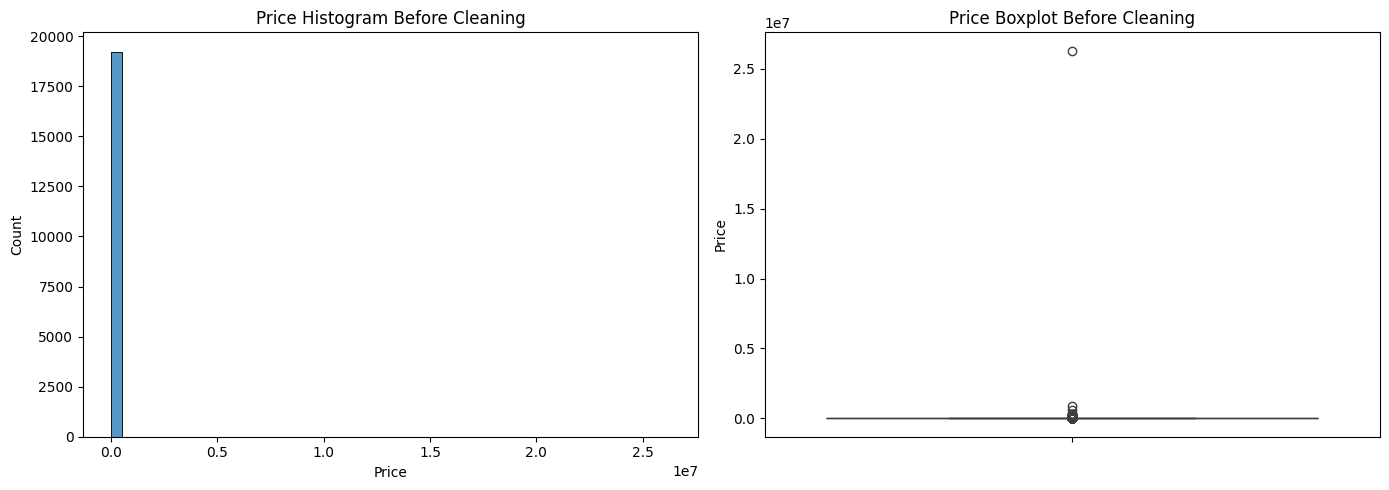

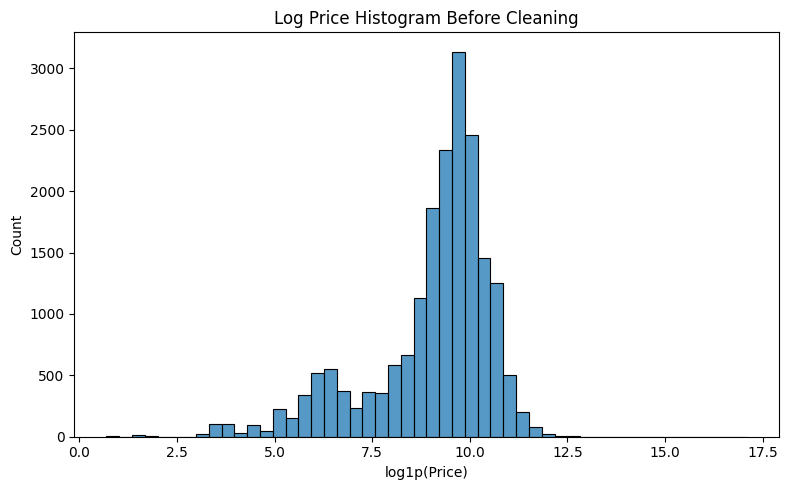


================ CATEGORICAL INSPECTION ================

--- Manufacturer ---
Manufacturer
HYUNDAI          3769
TOYOTA           3662
MERCEDES-BENZ    2076
FORD             1111
CHEVROLET        1069
BMW              1049
LEXUS             982
HONDA             977
NISSAN            660
VOLKSWAGEN        579
SSANGYONG         441
KIA               421
OPEL              397
MITSUBISHI        289
SUBARU            275
AUDI              255
MAZDA             183
JEEP              138
DAEWOO             91
DODGE              91
Name: count, dtype: int64

--- Model ---
Model
Prius         1083
Sonata        1079
Camry          938
Elantra        922
E 350          542
Santa FE       533
FIT            446
H1             437
Tucson         429
X5             353
Aqua           331
Cruze          302
Fusion         301
Optima         233
GX 460         224
Transit        217
Highlander     216
ML 350         202
Jetta          201
Actyon         188
Name: count, dtype: int64

--- Category 

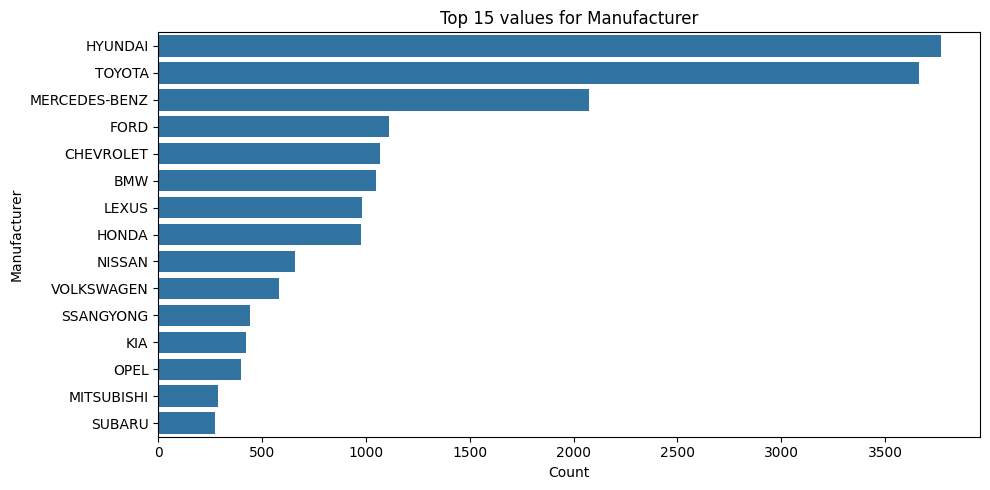

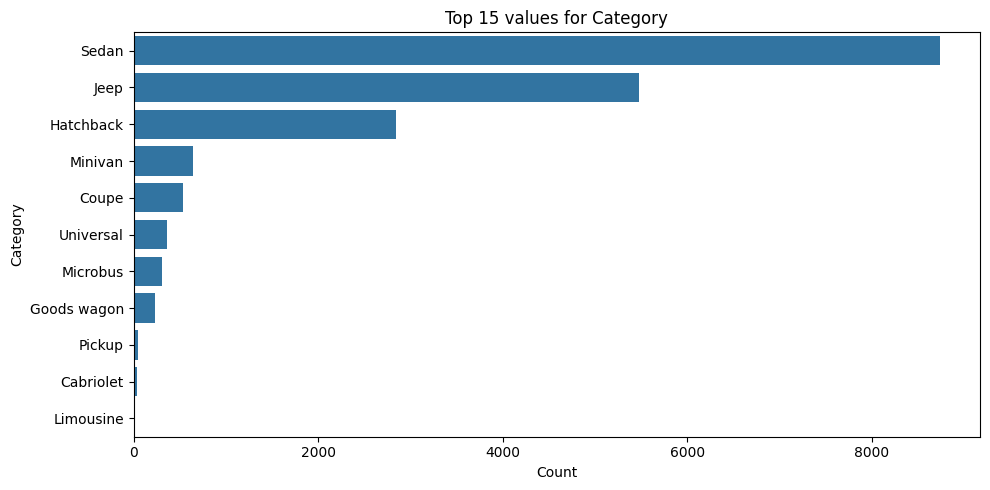

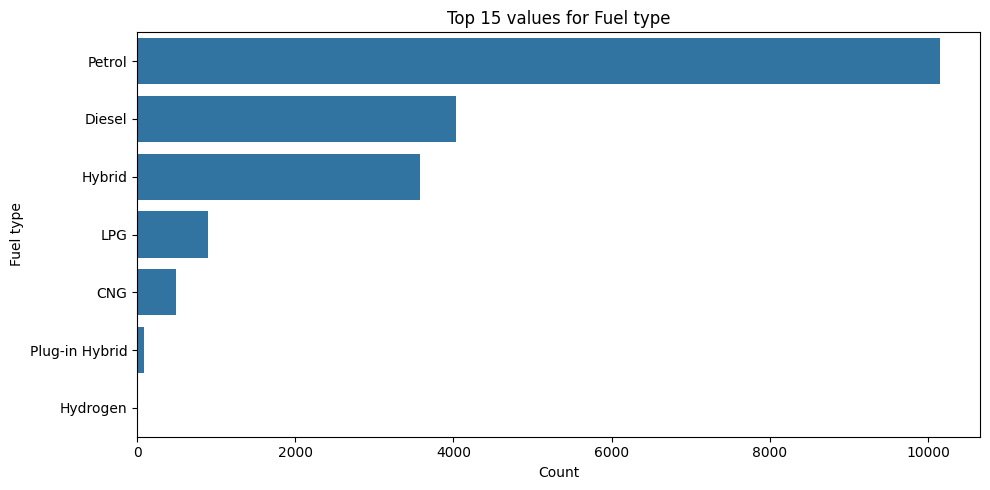


================ SUSPICIOUS RAW COLUMNS ================

--- Levy ---
Levy
-       5819
765      486
891      461
639      410
640      405
1017     298
781      297
707      270
642      265
836      260
779      252
777      246
585      214
831      208
1172     197
586      189
1399     188
761      183
730      170
1091     170
Name: count, dtype: int64

--- Mileage ---
Mileage
0 km         721
200000 km    183
150000 km    161
160000 km    120
100000 km    119
180000 km    118
1000 km      102
170000 km     99
120000 km     98
130000 km     86
111111 km     82
140000 km     75
190000 km     74
300000 km     67
250000 km     67
80000 km      64
145000 km     63
110000 km     61
90000 km      60
240000 km     59
Name: count, dtype: int64

--- Engine volume ---
Engine volume
2            3916
2.5          2277
1.8          1760
1.6          1462
1.5          1321
3.5          1228
2.4           987
3             823
1.3           518
2.0 Turbo     408
1.4           374
4.6        

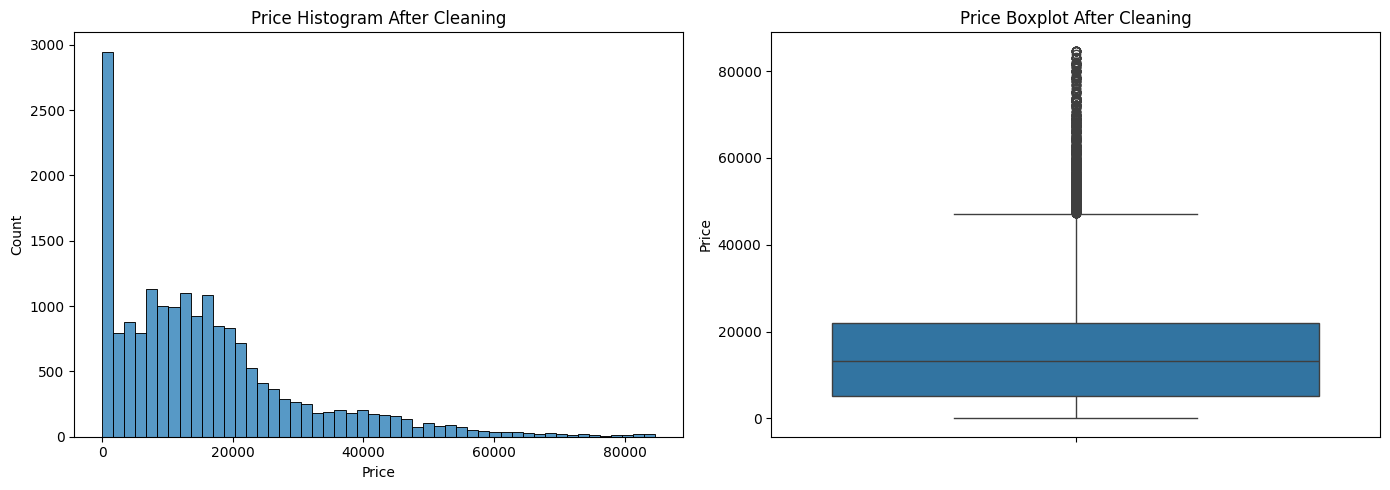

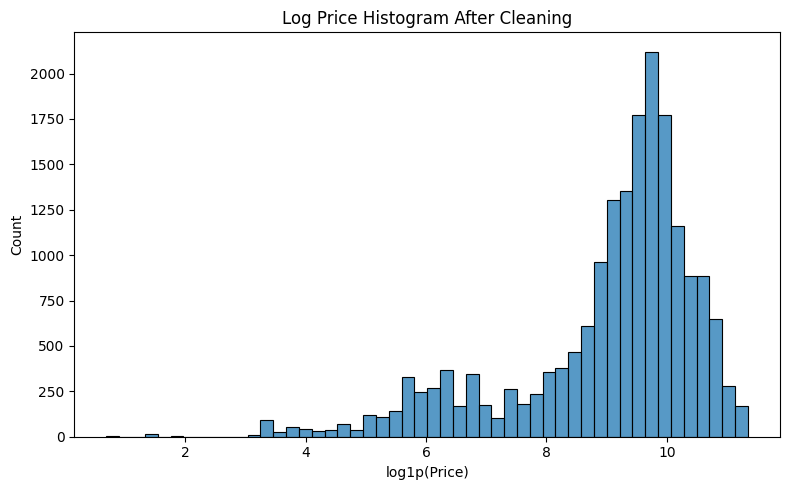


================ CLEANED NUMERIC PLOTS ================


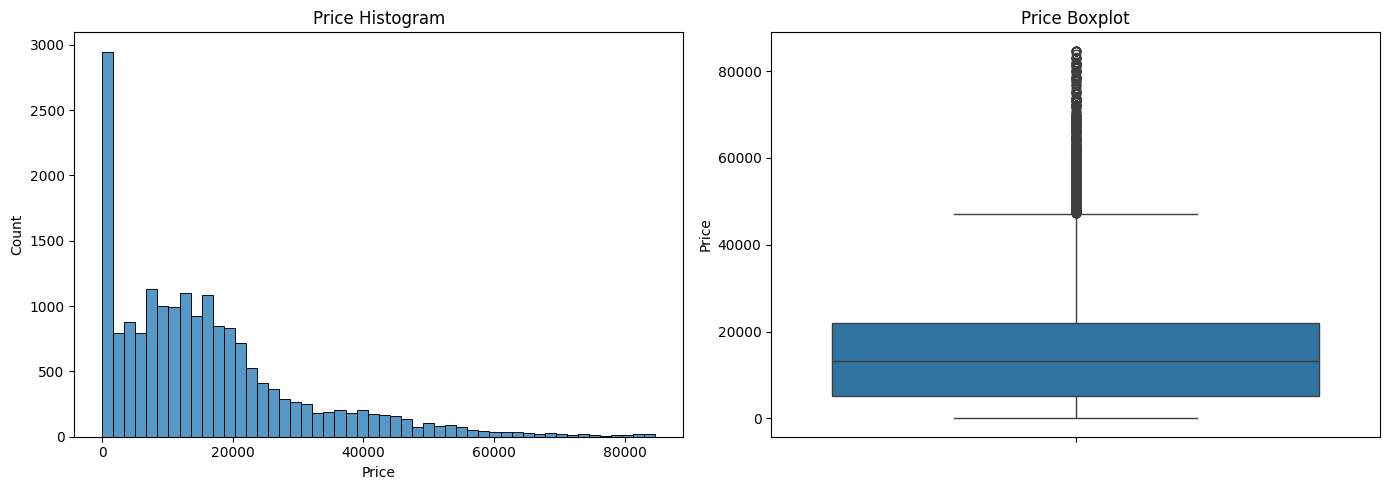

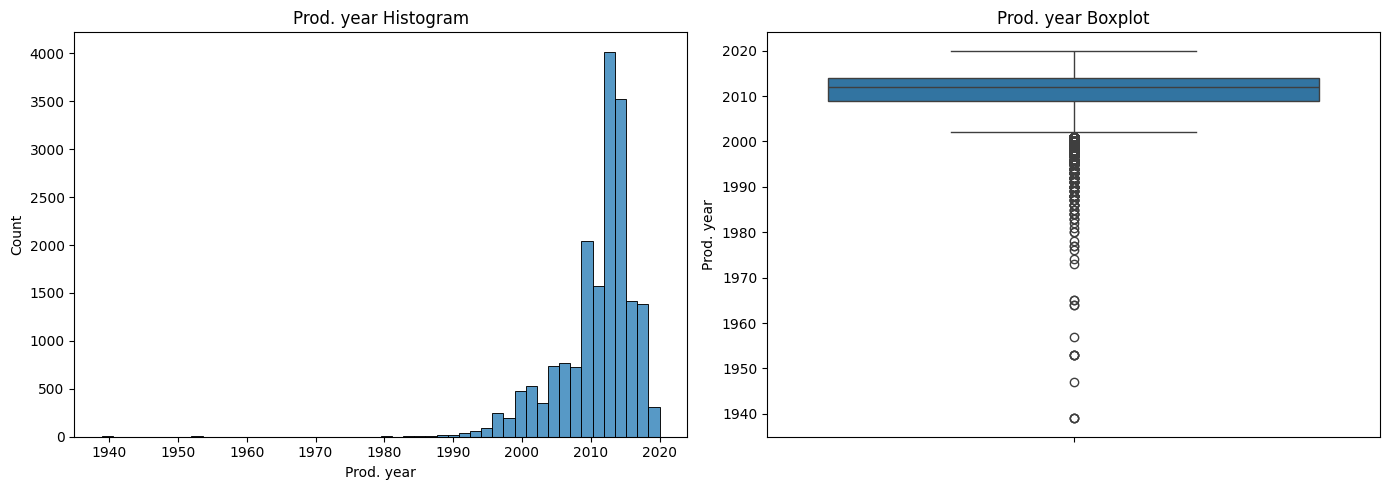

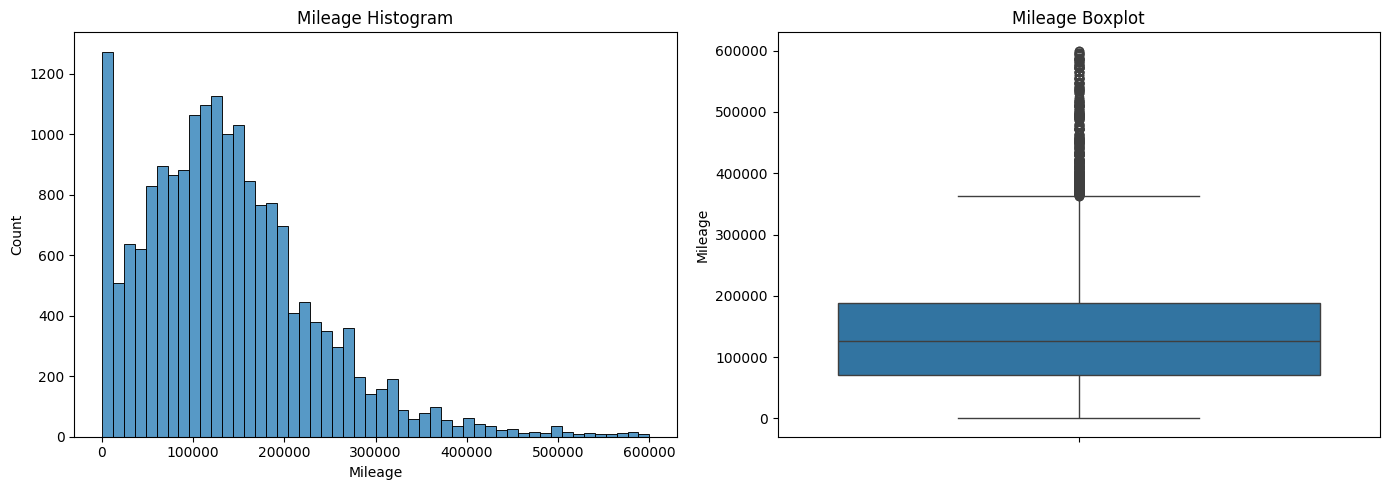

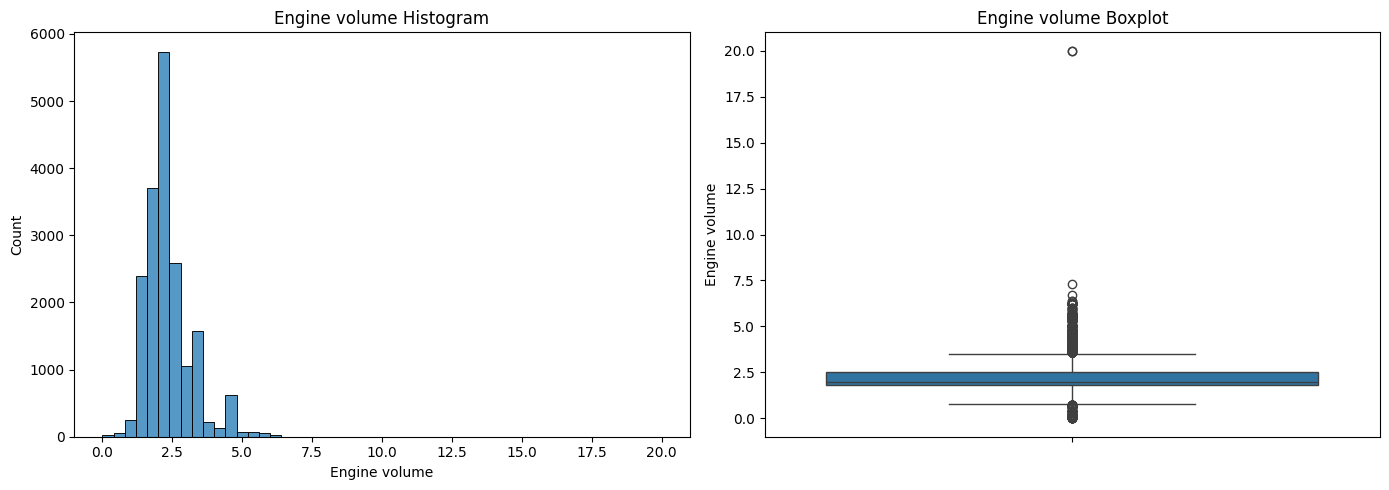

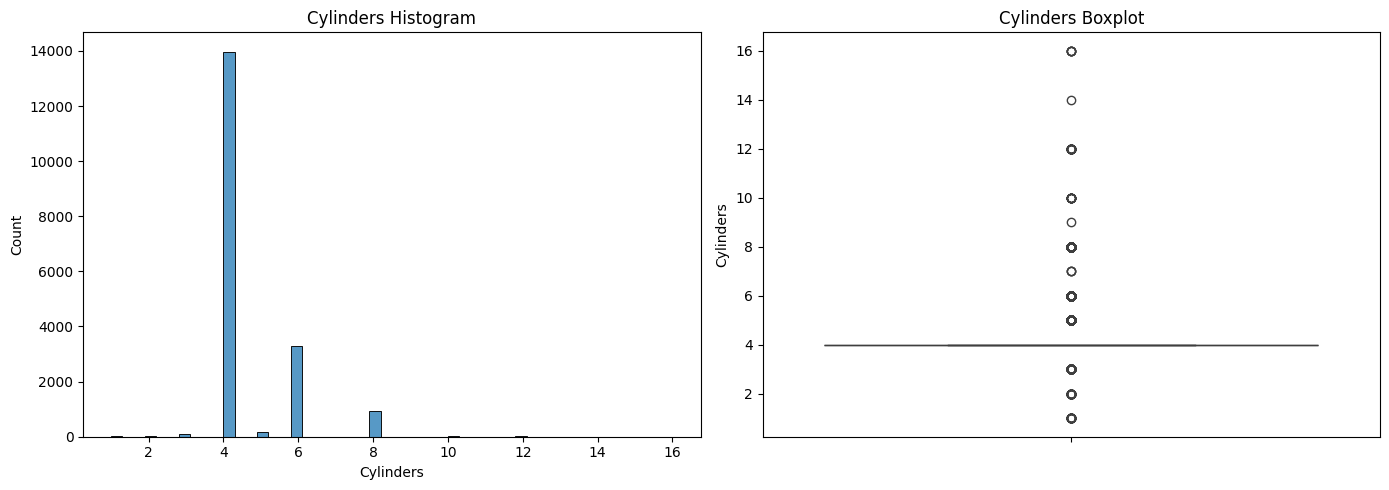

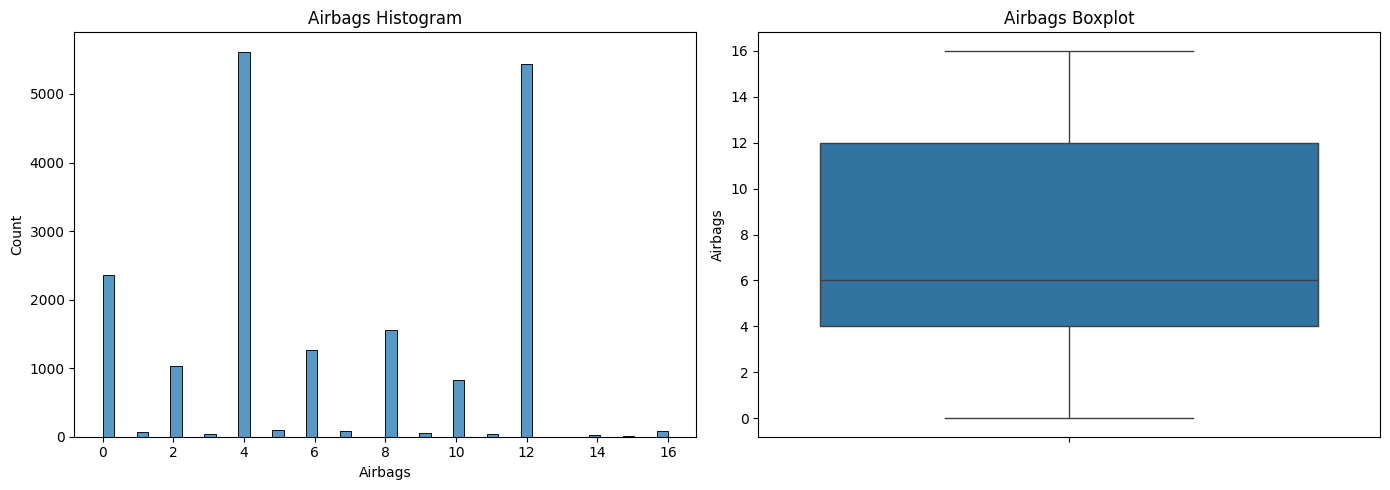

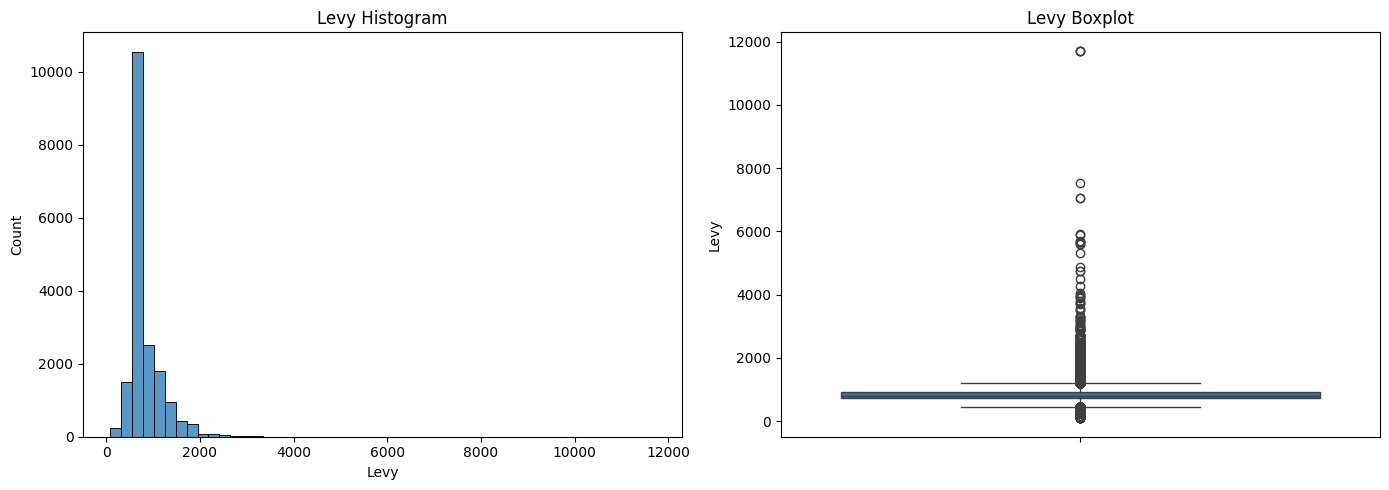


================ FINAL SHAPE ================
Raw shape: (19237, 18)
Clean shape: (18585, 18)


In [21]:
clean_df = main()

In [22]:
def prepare_features_target(df):
    """Prepare features and log-transformed target."""
    df = df.copy()

    X = df.drop(columns=[TARGET_COLUMN] + DROP_COLUMNS, errors="ignore")
    y = np.log1p(df[TARGET_COLUMN])

    return X, y


def build_baseline_model(X):
    """Build an interpretable linear regression baseline."""

    numeric_features = X.select_dtypes(
        include=["int64", "float64"]
    ).columns

    categorical_features = X.select_dtypes(
        include=["object", "category"]
    ).columns

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                "passthrough",
                numeric_features,
            ),
            (
                "categorical",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_features,
            ),
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", LinearRegression()),
        ]
    )

    return model


def build_random_forest_model(X):
    """Build a simple Random Forest regression model."""

    numeric_features = X.select_dtypes(
        include=["int64", "float64"]
    ).columns

    categorical_features = X.select_dtypes(
        include=["object", "category"]
    ).columns

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                "passthrough",
                numeric_features,
            ),
            (
                "categorical",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_features,
            ),
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "regressor",
                RandomForestRegressor(
                    n_estimators=200,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    min_samples_leaf=2,
                ),
            ),
        ]
    )

    return model


def evaluate_model(model, X_test, y_test, type):
    """Evaluate predictions on the original price scale."""
    log_predictions = model.predict(X_test)

    predictions = np.expm1(log_predictions)
    actuals = np.expm1(y_test)

    mae = mean_absolute_error(actuals, predictions)
    rmse = root_mean_squared_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)

    print(f"\n================ {type} MODEL RESULTS ================")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.3f}")


In [25]:
def main_models(clean_df):
    """Build models and fit and predict"""

    print("\n================ BASELINE MODEL ================")

    X, y = prepare_features_target(clean_df)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )

    baseline_model = build_baseline_model(X_train)
    baseline_model.fit(X_train, y_train)

    evaluate_model(
        baseline_model,
        X_test,
        y_test,
        type='Linear Regression'
    )

    print("\n================ RANDOM FOREST MODEL ================")

    random_forest_model = build_random_forest_model(X_train)
    random_forest_model.fit(X_train, y_train)

    evaluate_model(
        random_forest_model,
        X_test,
        y_test,
        type='Random Forest'
    )

    print("\n================ Fiat 500 prediction ================")

    fiat_500_example = pd.DataFrame({
        "Levy": [clean_df["Levy"].median()],
        "Manufacturer": ["FIAT"],
        "Model": ["500"],
        "Prod. year": [2011],
        "Category": ["Hatchback"],
        "Leather interior": ["No"],
        "Fuel type": ["Petrol"],
        "Engine volume": [1.2],
        "Mileage": [120000],
        "Cylinders": [4.0],
        "Gear box type": ["Manual"],
        "Drive wheels": ["Front"],
        "Doors": ["04-May"],
        "Wheel": ["Left wheel"],
        "Color": ["White"],
        "Airbags": [4],
    })

    log_prediction = random_forest_model.predict(fiat_500_example)
    predicted_price = np.expm1(log_prediction)

    print(f"Predicted Fiat 500 price: {predicted_price[0]:,.2f}")

In [26]:
main_models(clean_df)


================ BASELINE MODEL ================

================ Linear Regression MODEL RESULTS ================
MAE:  9,582.81
RMSE: 14,149.77
R²:   0.119

================ RANDOM FOREST MODEL ================

================ Random Forest MODEL RESULTS ================
MAE:  4,355.25
RMSE: 7,971.64
R²:   0.720

================ Fiat 500 prediction ================
Predicted Fiat 500 price: 10,691.26
